# Reflection laboratory

A reflection across the line spanned by a unit vector $\vec u$ is

$$
R=2\vec u\vec u^{\mathsf T}-I.
$$

The first experiment separates a vector into the component retained by the mirror and the component whose sign is reversed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

paper='#fbf4e8'; ink='#30241d'; purple='#6c4ccf'; coral='#dd6b55'; teal='#3d8c7a'; gold='#dfaa3f'; grid='#d9cfc1'

def style(ax, limit=4.2):
    ax.set_facecolor(paper)
    ax.axhline(0,color=ink,lw=1); ax.axvline(0,color=ink,lw=1)
    ax.grid(color=grid,alpha=.5); ax.set_aspect('equal')
    ax.set_xlim(-limit,limit); ax.set_ylim(-limit,limit)
    for spine in ax.spines.values(): spine.set_visible(False)

def arrow(ax, origin, vector, color, label, offset=(.10,.12), width=.035):
    origin=np.asarray(origin,dtype=float); vector=np.asarray(vector,dtype=float)
    ax.arrow(*origin,*vector,length_includes_head=True,head_width=.18,head_length=.24,linewidth=2,width=width,color=color,zorder=4)
    tip=origin+vector
    ax.text(tip[0]+offset[0],tip[1]+offset[1],label,color=color,fontsize=12,weight='bold')

theta=np.deg2rad(30)
u=np.array([np.cos(theta),np.sin(theta)])
n=np.array([-u[1],u[0]])
R=2*np.outer(u,u)-np.eye(2)
x=np.array([1.8,3.2])
x_parallel=(u@x)*u
x_perpendicular=x-x_parallel
x_reflected=R@x

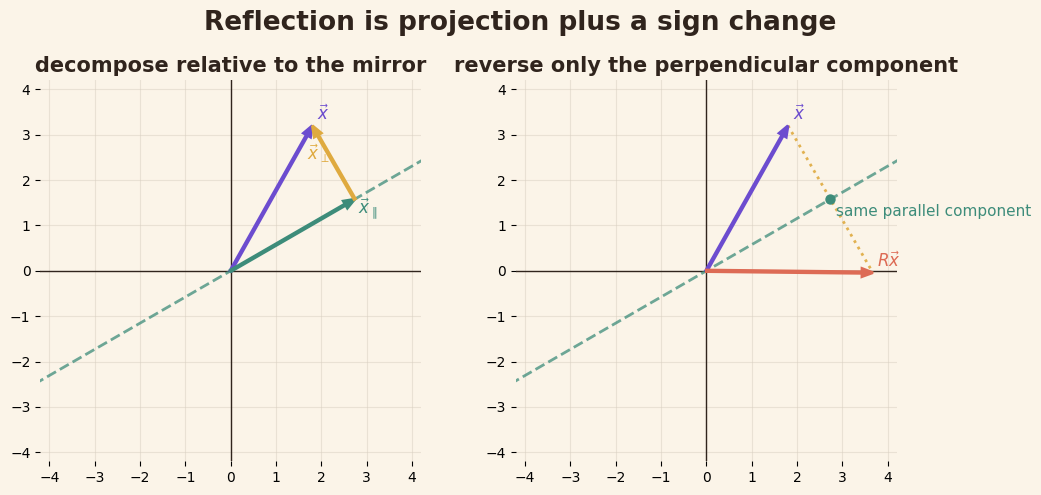

In [2]:
fig,axes=plt.subplots(1,2,figsize=(11,5),facecolor=paper)
for ax in axes:
    style(ax)
    line=np.linspace(-5,5,2)
    ax.plot(line*u[0],line*u[1],color=teal,lw=2,ls='--',alpha=.75)

arrow(axes[0],(0,0),x,purple,r'$\vec x$')
arrow(axes[0],(0,0),x_parallel,teal,r'$\vec x_{\parallel}$',offset=(.08,-.34))
arrow(axes[0],x_parallel,x_perpendicular,gold,'')
perpendicular_midpoint=x_parallel+.5*x_perpendicular
axes[0].text(perpendicular_midpoint[0]-.58,perpendicular_midpoint[1]+.06,r'$\vec x_{\perp}$',color=gold,fontsize=12,weight='bold')
axes[0].set_title('decompose relative to the mirror',color=ink,fontsize=15,weight='bold')

arrow(axes[1],(0,0),x,purple,r'$\vec x$')
arrow(axes[1],(0,0),x_reflected,coral,r'$R\vec x$')
axes[1].plot([x[0],x_reflected[0]],[x[1],x_reflected[1]],color=gold,lw=2,ls=':',alpha=.9)
axes[1].scatter(*x_parallel,color=teal,s=42,zorder=5)
axes[1].text(x_parallel[0]+.12,x_parallel[1]-.38,'same parallel component',color=teal,fontsize=11)
axes[1].set_title('reverse only the perpendicular component',color=ink,fontsize=15,weight='bold')

fig.suptitle('Reflection is projection plus a sign change',color=ink,fontsize=19,weight='bold')
fig.tight_layout(); plt.show()

## A whole figure follows the same rule

A matrix acts on every point. The topology and all distances inside the polygon survive, while orientation changes.

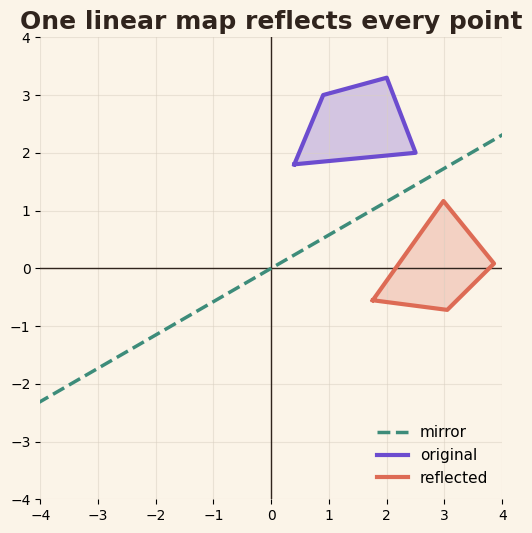

In [3]:
shape=np.array([[.4,1.8],[2.5,2.0],[2.0,3.3],[.9,3.0],[.4,1.8]])
reflected=shape@R.T
fig,ax=plt.subplots(figsize=(7,6),facecolor=paper); style(ax,4.0)
line=np.linspace(-5,5,2); ax.plot(line*u[0],line*u[1],color=teal,lw=2.5,ls='--',label='mirror')
ax.fill(shape[:,0],shape[:,1],color=purple,alpha=.28); ax.plot(shape[:,0],shape[:,1],color=purple,lw=3,label='original')
ax.fill(reflected[:,0],reflected[:,1],color=coral,alpha=.25); ax.plot(reflected[:,0],reflected[:,1],color=coral,lw=3,label='reflected')
ax.legend(frameon=False,loc='lower right',fontsize=11)
ax.set_title('One linear map reflects every point',color=ink,fontsize=18,weight='bold')
plt.show()

## The mirror and its normal are eigendirections

The mirror direction satisfies $R\vec u=\vec u$. Its eigenvalue is $+1$. The normal satisfies $R\vec n=-\vec n$. Its eigenvalue is $-1$.

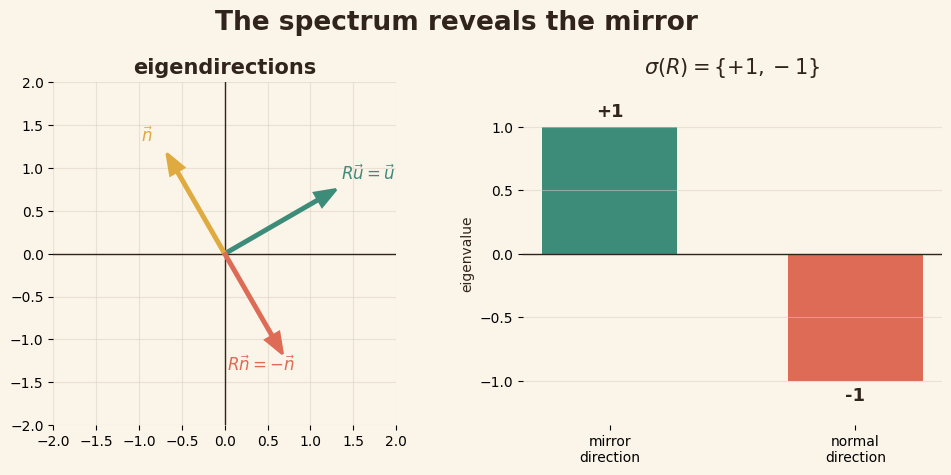

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4.8),facecolor=paper)
style(axes[0],2.0)
arrow(axes[0],(0,0),1.5*u,teal,r'$R\vec u=\vec u$',offset=(.06,.12),width=.025)
arrow(axes[0],(0,0),1.35*n,gold,r'$\vec n$',offset=(-.30,.14),width=.025)
arrow(axes[0],(0,0),-1.35*n,coral,r'$R\vec n=-\vec n$',offset=(-.65,-.20),width=.025)
axes[0].set_title('eigendirections',color=ink,fontsize=15,weight='bold')

axes[1].set_facecolor(paper)
axes[1].bar(['mirror\ndirection','normal\ndirection'],[1,-1],color=[teal,coral],width=.55)
axes[1].axhline(0,color=ink,lw=1); axes[1].grid(axis='y',color=grid,alpha=.5)
axes[1].set_ylim(-1.35,1.35); axes[1].set_ylabel('eigenvalue',color=ink)
axes[1].set_title(r'$\sigma(R)=\{+1,-1\}$',color=ink,fontsize=15,weight='bold')
for spine in axes[1].spines.values(): spine.set_visible(False)
for index,value in enumerate([1,-1]): axes[1].text(index,value+(.08 if value>0 else -.16),f'{value:+d}',ha='center',color=ink,fontsize=13,weight='bold')

fig.suptitle('The spectrum reveals the mirror',color=ink,fontsize=19,weight='bold')
fig.tight_layout(); plt.show()

assert np.allclose(R@u,u)
assert np.allclose(R@n,-n)
assert np.allclose(R@R,np.eye(2))
assert np.allclose(R.T@R,np.eye(2))
assert np.isclose(np.linalg.det(R),-1)

## Conclusion

The mirror is not an extra graphical object placed beside the matrix. It is encoded by the $+1$ eigenspace of the transformation; its perpendicular direction is encoded by the $-1$ eigenspace.